### Take a look at Mount Roberts Tram Met Station Data... 

created by Cassie Lumbrazo\
last updated: April 2026\
run location: UAS linux\
python environment: **rasterio**

In [2]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from zoneinfo import ZoneInfo
from pathlib import Path

In [3]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tram'

## Load Tram Met Station Dataset

In [12]:
# filename = '/hdd/snow_hydrology/met_station/tram/JTMA2_MountRoberts_Tram_Synoptic_everything_utc_until_2025-10-08.csv'
filename = '/hdd/snow_hydrology/met_station/tram/JTMA2.2026-03-20.csv' # this one is everything downloaded until 20 March 2026 
tram_met = pd.read_csv(filename, sep = ",", low_memory=False, skiprows=10)
tram_met['datetime'] = pd.to_datetime(tram_met['Date_Time'], utc=True)
# set datetime as the index
tram_met = tram_met.iloc[1:].copy() # skipping that first row since it's the units row
tram_met.set_index('datetime', inplace=True)
tram_met.head()

,Station_ID,Date_Time,air_temp_set_1,relative_humidity_set_1,wind_speed_set_1,wind_direction_set_1,wind_gust_set_1,snow_depth_set_1,solar_radiation_set_1,precip_accum_set_1,volt_set_1,snow_interval_set_1,wind_chill_set_1d,wind_cardinal_direction_set_1d,heat_index_set_1d,dew_point_temperature_set_1d
datetime,,,,,,,,,,,,,,,,
2014-08-27 03:00:00+00:00,JTMA2,2014-08-27T03:00:00Z,8.92,100.0,NaN,NaN,NaN,NaN,NaN,1.524,NaN,NaN,NaN,NaN,NaN,8.92
2014-08-27 03:15:00+00:00,JTMA2,2014-08-27T03:15:00Z,8.9,100.0,NaN,NaN,NaN,NaN,NaN,0.508,NaN,NaN,NaN,NaN,NaN,8.9
2014-08-27 03:30:00+00:00,JTMA2,2014-08-27T03:30:00Z,8.83,100.0,NaN,NaN,NaN,NaN,NaN,0.508,NaN,NaN,NaN,NaN,NaN,8.83
2014-08-27 03:45:00+00:00,JTMA2,2014-08-27T03:45:00Z,8.8,100.0,NaN,NaN,NaN,NaN,NaN,0.508,NaN,NaN,NaN,NaN,NaN,8.8
2014-08-27 04:00:00+00:00,JTMA2,2014-08-27T04:00:00Z,8.8,100.0,NaN,NaN,NaN,NaN,NaN,0.762,NaN,NaN,NaN,NaN,NaN,8.8


<Axes: xlabel='datetime'>

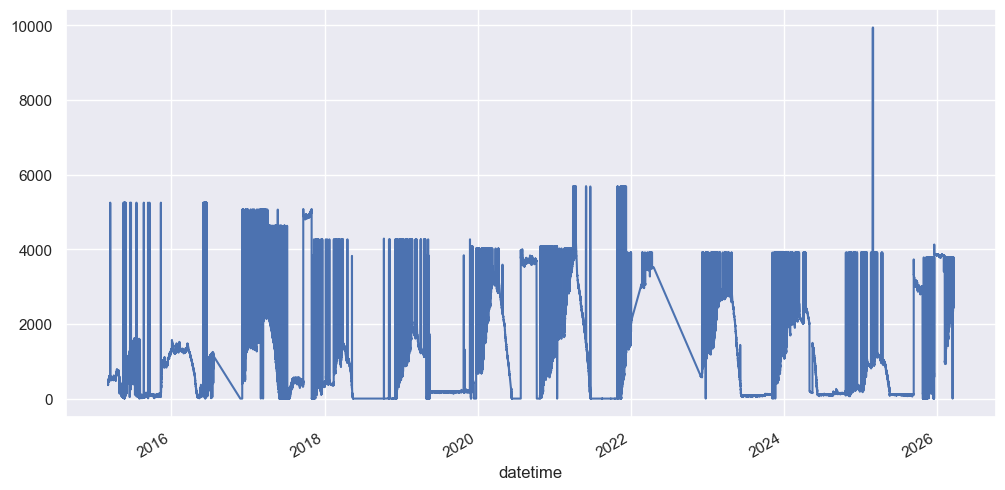

In [13]:
tram_met['snow_depth_set_1'] = pd.to_numeric(tram_met['snow_depth_set_1'], errors='coerce')
tram_met['snow_depth_set_1'].plot()

<Axes: xlabel='datetime'>

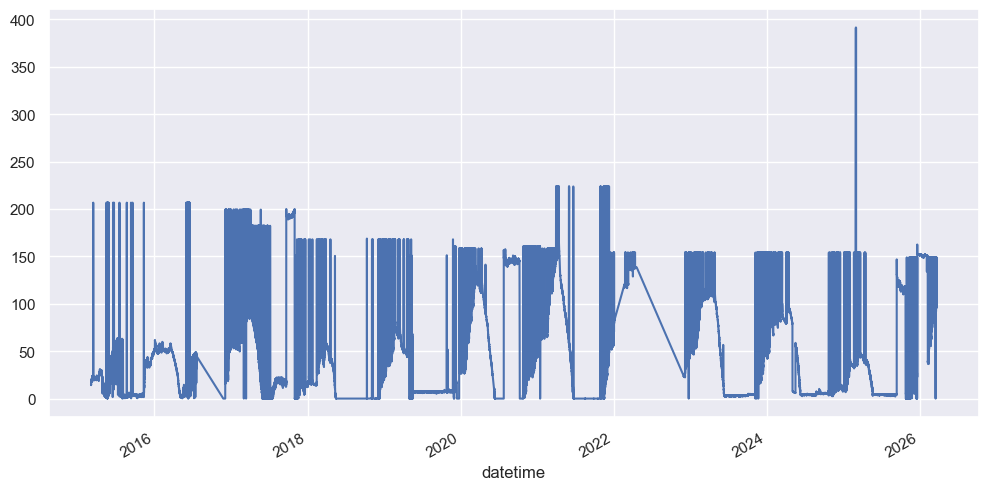

In [14]:
# convert mm to inches 
tram_met['snow_depth_set_1_inches'] = tram_met['snow_depth_set_1'] / 25.4  # convert mm to inches
tram_met['snow_depth_set_1_inches'].plot()

<Axes: xlabel='datetime'>

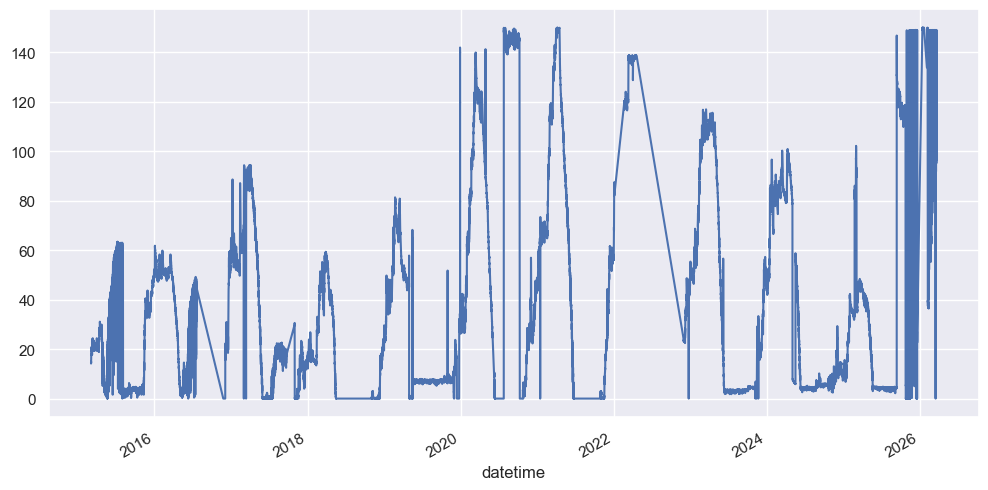

In [15]:
# drop any values above 150 and below 0 
tram_met_clean = tram_met[(tram_met['snow_depth_set_1_inches'] <= 150) & (tram_met['snow_depth_set_1_inches'] >= 0)]
tram_met_clean['snow_depth_set_1_inches'].plot()

<Axes: xlabel='datetime'>

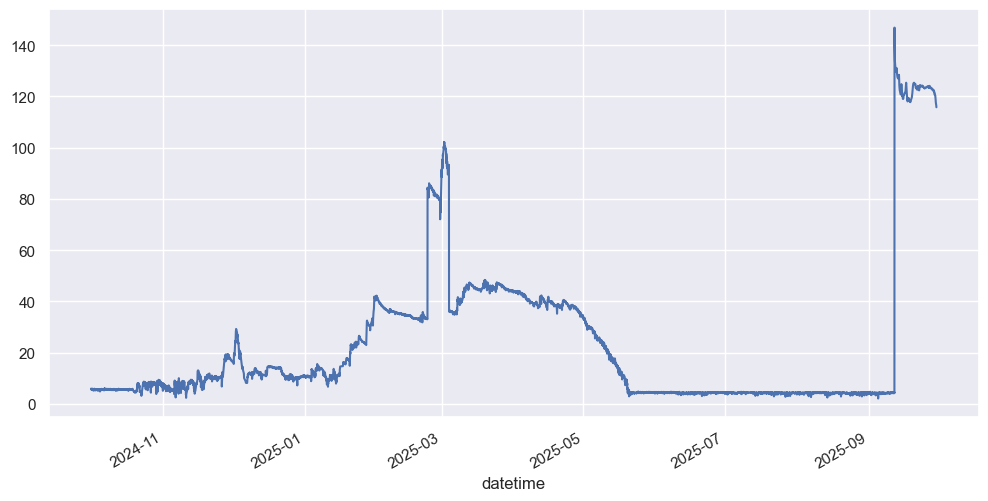

In [18]:
# cut to WY2025 which is from 1 October 2024 to 30 September 2025
wy2025_start = pd.Timestamp('2024-10-01', tz='UTC')
wy2025_end = pd.Timestamp('2025-09-30', tz='UTC')
tram_met_WY2025 = tram_met_clean[(tram_met_clean.index >= wy2025_start) & (tram_met_clean.index <= wy2025_end)]
tram_met_WY2025['snow_depth_set_1_inches'].plot()

In [19]:
# save tram_met_WY2025 to a new csv file 
output_filename = '/hdd/snow_hydrology/met_station/tram/tram_met_WY2025_clean_temporary.csv'
tram_met_WY2025.to_csv(output_filename)

## Load HRRR-AK at the Tram

In [4]:
input_file = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2025_utm_site_tram.nc"
ds = xr.open_dataset(input_file)
ds.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds

<xarray.Dataset> Size: 2MB
Dimensions:       (time: 8760)
Coordinates:
  * time          (time) datetime64[ns] 70kB 2024-10-01T05:00:00 ... 2025-10-...
    valid_time    (time) datetime64[ns] 70kB ...
    step          (time) timedelta64[ns] 70kB ...
    y             float64 8B ...
    x             float64 8B ...
    spatial_ref   int64 8B 0
Data variables: (12/28)
    gust          (time) float64 70kB ...
    pressure      (time) float64 70kB ...
    orog          (time) float64 70kB ...
    temp_surface  (time) float64 70kB ...
    swe           (time) float64 70kB ...
    snowdepth     (time) float64 70kB ...
    ...            ...
    swrad         (time) float64 70kB ...
    lwrad         (time) float64 70kB ...
    suswrf        (time) float64 70kB ...
    sulwrf        (time) float64 70kB ...
    wind          (time) float64 70kB ...
    wind_dir      (time) float64 70kB ...
Attributes: (12/13)
    long_name:       Wind speed (gust)
    units:           m s**-1
    GRIB_shortName:  gust
    GRIB_name:       Wind speed (gust)
    GRIB_cfName:     unknown
    GRIB_cfVarName:  gust
    ...              ...
    typeOfLevel:     surface
    site_name:       tram
    original_lat:    58.2971
    original_lon:    -134.386
    utm_x:           535991.6505796042
    utm_y:           6461952.074115438